# Projet ML Groupe 1

- BEGOT Matis - 22012080
- HAFDANE Léo - 22202516
- LOPEZ Hugo - 22302106
- BONNAFÉ Rémi - 22208924
- DEJEAN Robin - 22110437

In [83]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import joblib
import re
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import sys

from sklearn.model_selection import train_test_split
from plotly.subplots import make_subplots
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.feature_extraction.text import CountVectorizer   # Sac de mots
from sklearn.feature_extraction.text import TfidfVectorizer    # TF-IDF
from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS  #Stop words English
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
import pickle
import nltk
import shutil
import os
import glob
import warnings

import optuna
import joblib

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    accuracy_score,  # Précision globale
    precision_score,  # Précision
    recall_score,  # Rappel
    f1_score,  # F1-Score
    confusion_matrix,  # Matrice de confusion
    roc_auc_score,  # AUC (Area Under the Curve)
    roc_curve,  # Courbe ROC
    classification_report,  # Rapport de classification
    mean_squared_error,  # Erreur quadratique moyenne (MSE)
    mean_absolute_error,  # Erreur absolue moyenne (MAE)
    r2_score,  # Coefficient de détermination R²
    auc  # Calcul de l'AUC
)
from sklearn.exceptions import ConvergenceWarning

# Librairies pour LDA
import gensim                    # Modélisation des topics et NLP
from gensim import corpora       # Création du dictionnaire de mots
from gensim.models import LdaModel  # Modèle LDA simple
from gensim.utils import simple_preprocess  # Prétraitement simple des textes
from gensim.models import CoherenceModel    # Calcul de la cohérence des topics
from gensim.models import Phrases           # Création de bigrammes/trigrammes
from gensim.models.phrases import Phraser   # Optimisation bigrammes/trigrammes
from gensim import corpora, models          # Utilisation des modèles
from gensim.models import LdaMulticore      # Modèle LDA parallèle
import multiprocessing                      # Gestion du multi-threading


nltk_data_dir = './nltk_data'


# On laisse au cas où
# # Aggressively clean corrupted NLTK data
# if os.path.exists(nltk_data_dir):
#     shutil.rmtree(nltk_data_dir)
# # Also remove any corrupted zip files from system paths
# for path in nltk.data.path:
#     if os.path.exists(path):
#         for zipfile in glob.glob(os.path.join(path, '*.zip')):
#             try:
#                 os.remove(zipfile)
#             except:
#                 pass

# Create fresh nltk_data directory
os.makedirs(nltk_data_dir, exist_ok=True)
nltk.data.path.insert(0, nltk_data_dir)

# Download resources with fresh start
print("Downloading NLTK resources...")
nltk.download('wordnet', download_dir=nltk_data_dir, quiet=True)
nltk.download('omw-1.4', download_dir=nltk_data_dir, quiet=True)
nltk.download('wordnet_ic', download_dir=nltk_data_dir, quiet=True)
nltk.download('averaged_perceptron_tagger', download_dir=nltk_data_dir, quiet=True)
print("NLTK resources downloaded successfully!")

from nltk.corpus import wordnet
from nltk.stem.snowball import SnowballStemmer

from contraction_fix import fix as expand_contractions # Contraction

import spacy                                # NLP avancé
from spacy import displacy                  # Visualisation
from spacy.cli import download

NLTK resources downloaded successfully!


In [85]:
download("en_core_web_sm")
nlp = spacy.load("en_core_web_sm")

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Préprocess

In [89]:
def stop_words(text):
    # Normalisation des apostrophes
    text = text.replace("’", "'")
    tokens = text.split()
    expanded = []
    for t in tokens:
        key = t.lower()
        if key not in ENGLISH_STOP_WORDS:
            expanded.append(t)
    return " ".join(expanded)

text = "I'm happy but I don't know why."
print(text)
print(stop_words(expand_contractions(text)))

I'm happy but I don't know why.
happy know why.


In [90]:
stemmer = nltk.stem.porter.PorterStemmer()
lemmatizer = nltk.stem.WordNetLemmatizer()

def stemmerLemma(text):
    # apostrophes bizarre en pas bizarre (encore)
    text = text.replace("’", "'")
    expanded = []
    t2 = nlp(text)
    
    for t in t2:
        
        key = t.text.lower()
        # print(key, t.pos_, stemmer.stem(key), lemmatizer.lemmatize(key))
        if t.pos_ == "VERB":
            result = stemmer.stem(key)
        elif t.pos_ == "NOUN" or t.pos_ == "ADJ" or t.pos_ == "PROPN":
            result = lemmatizer.lemmatize(key)
        else:
            result = key
        expanded.append(result)
    return " ".join(expanded)

In [104]:
emoticons_str = r"""
    (?:
        [:=;] # Yeux
        [oO\-]? # Nez (pas tout le temps)
        [D\)\]\(\]/\\OpP] # Bouche
    )"""
html_str = r"<[^>]+>"
mentions_str = r"(?:@[\w_]+)"
hashtags_str = r"(?:\#+[\w_]+[\w\'_\-]*[\w_]+)"
url_str = r"http[s]?://(?:[a-z]|[0-9]|[$-_@.&amp;+]|[!*\(\),]|(?:%[0-9a-f][0-9a-f]))+"
number_str = r"(?:(?:\d+,?)+(?:\.?\d+)?)"
compose_str = r"(?:[a-z][a-z'\-_]+[a-z])"
mots_str = r"(?:[\w_]+)"
reste_str = r"(?:[\S]+)"

total_str = [
    emoticons_str,
    html_str,
    mentions_str,
    hashtags_str,
    url_str,
    number_str,
    compose_str,
    mots_str,
    reste_str,
]

emoticons_regex = re.compile(emoticons_str, re.VERBOSE | re.IGNORECASE)
html_regex = re.compile(html_str, re.VERBOSE | re.IGNORECASE)
mentions_regex = re.compile(mentions_str, re.VERBOSE | re.IGNORECASE)
hashtags_regex = re.compile(hashtags_str, re.VERBOSE | re.IGNORECASE)
url_regex = re.compile(url_str, re.VERBOSE | re.IGNORECASE)
number_regex = re.compile(number_str, re.VERBOSE | re.IGNORECASE)
compose_regex = re.compile(compose_str, re.VERBOSE | re.IGNORECASE)
mots_regex = re.compile(mots_str, re.VERBOSE | re.IGNORECASE)
reste_regex = re.compile(reste_str, re.VERBOSE | re.IGNORECASE)
total_regex = re.compile(r'('+'|'.join(total_str)+')', re.VERBOSE | re.IGNORECASE)

def preprocess(s, emoticons=False, html=False, mentions=False, hashtags=False, url=False, number=False, compose=True,
               stemmerlemma=True, stopwords=True):
    tokens = total_regex.findall(s)

    tokens = [tok for tok in tokens if 
        mots_regex.search(tok) and
        (emoticons or not emoticons_regex.search(tok)) and
        (html or not html_regex.search(tok)) and
        (mentions or not mentions_regex.search(tok)) and
        (hashtags or not hashtags_regex.search(tok)) and
        (url or not url_regex.search(tok)) and
        (number or not number_regex.search(tok)) and
        (compose or not compose_regex.search(tok))
    ]
            
    sentence = " ".join(tokens)
    if stemmerlemma:
        sentence = stemmerLemma(sentence)
    if stopwords:
        sentence = stop_words(sentence)
        
    return sentence

preprocess("This is an example, ! of #CountVectorizer for creating a vector https://leotta.ro 런쥔을공평하게_대하세요")
# print(preprocess("This is another example of CountVectorizer"))
# print(preprocess("with or without parameters"))

'example creat vector 런쥔을공평하게_대하세요'

# Répartition des données (upsampling / downsampling / rien)

In [92]:
#sampling="nothing"
#sampling="up"
# sampling="down"
sampling="weighted"

column="science_related"
# column="scientific_claim"
# column="scientific_reference"
# column="scientific_context"

# ---------------------------------------------------------------
# ------------------------- PAS TOUCHER -------------------------
# ---------------------------------------------------------------

df_lue=pd.read_csv('scitweets_export.tsv', sep='\t')
print(f"df d'origine : {len(df_lue)} lignes")

# 0. ça aide
if column=="science_related":
    tache_res_display = ["pas scientifique", "scientifique"]
if column=="scientific_claim":
    tache_res_display = ["pas claim", "claim"]
if column=="scientific_reference":
    tache_res_display = ["pas référence", "référence"]
if column=="scientific_context":
    tache_res_display = ["pas context", "context"]

# 1. Si on spécifie une colonne précisée scientifique, on ne travaille que sur la df des tweets scientifiques
if column != "science_related":
    df_lue = df_lue[df_lue["science_related"] == 1].reset_index(drop=True)
    print(f"df filtrée : {len(df_lue)} lignes")
    
# 2. Séparer le jeu de donné
texte = [preprocess(t) for t in df_lue.text]
X_train_related, X_test_related, y_train_related, y_test_related = train_test_split(
    texte, df_lue[column], test_size=0.2, stratify=df_lue[column], random_state=42
)

X = X_train_related + X_test_related
y = list(y_train_related) + list(y_test_related)
print(f"Train sur {len(X_train_related)} lignes, test sur {len(X_test_related)}")

df d'origine : 1140 lignes
Train sur 912 lignes, test sur 228


# Benchmark des models

In [105]:
# 1. Fonction pour sample un x et un Y.
def sample_data(X, y):
    #y_series = pd.Series(y if isinstance(y, list) else y.values)
    y_series = pd.Series(y)
    X_series = pd.Series(X)

    idx_min = y_series[y_series == 0].index
    idx_max = y_series[y_series == 1].index
    if len(idx_min) > len(idx_max):
        idx_min, idx_max = idx_max, idx_min

    nb_lignes_min = len(idx_min)
    nb_lignes_max = len(idx_max)

    if sampling == "up":
        idx_min = idx_min.to_series().sample(n=nb_lignes_max, replace=True, random_state=42).index
    elif sampling == "down":
        idx_max = idx_max.to_series().sample(n=nb_lignes_min, random_state=42).index

    idx_final = pd.Series(idx_min.tolist() + idx_max.tolist()).sample(frac=1, random_state=42).values
    return X_series[idx_final].tolist(), y_series[idx_final].tolist()

# 2. Liste des modèles
if sampling == "weighted":
    models = [
        ("KNN", "cornflowerblue", None),
        ("DecisionTree", "orange", None),        
        ("MultinomialNB (fit_prior=True)", "limegreen", MultinomialNB(fit_prior=True)),
        ("LinearSVC", "firebrick", LinearSVC(class_weight="balanced")),
        ("RandomForest", "darkorchid", RandomForestClassifier(class_weight='balanced'))
    ]
else:
    models = [
        ("KNN", "cornflowerblue", KNeighborsClassifier()),
        ("DecisionTree", "orange", DecisionTreeClassifier()),
        ("MultinomialNB (fit_prior=False)", "limegreen", MultinomialNB(fit_prior=False)),
        ("LinearSVC", "firebrick", LinearSVC()),
        ("RandomForest", "darkorchid", RandomForestClassifier())
    ]

metriques = ["accuracy", "f1_macro"]

names = []
colors = []
results = {m:[] for m in metriques}

texte = [preprocess(t) for t in df_lue.text]
X_train_related = texte
y_train_related = df_lue[column].values
print(len(X_train_related), len(y_train_related))

seed = 42
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)

print("Début de l'évaluation des modèles...\n")

for name, color, model in models:
    if model is None:
        continue
            
    names.append(name)
    colors.append(color)
    print(f"{"-"*15} Modèle : {name} {"-"*15}")
    fold_accuracies = []
    fold_f1_macros = []

    # On sample les données de test et de train séparément. On sample sur les indices pour garder les données X et Y synchronisées
    for fold, (fold_train_idx, fold_val_idx) in enumerate(kfold.split(X_train_related, y_train_related)):
        X_fold_train = [X_train_related[i] for i in fold_train_idx]
        y_fold_train = y_train_related[fold_train_idx]
        
        X_fold_val = [X_train_related[i] for i in fold_val_idx]
        y_fold_val = y_train_related[fold_val_idx]

        if sampling == "up" or sampling == "down":
            X_fold_train_resampled, y_fold_train_resampled = sample_data(X_fold_train, y_fold_train)
        else:
            X_fold_train_resampled, y_fold_train_resampled = X_fold_train, y_fold_train
    
        # la pipeline utilise nos donnés samplés
        pipeline = Pipeline([
            ("vectorizer", TfidfVectorizer(lowercase=False, ngram_range=(1, 2))),
            ("model", model)
        ])
        pipeline.fit(X_fold_train_resampled, y_fold_train_resampled)
            
        # On stocke les scores du pli
        y_pred_val = pipeline.predict(X_fold_val)
        fold_accuracies.append(accuracy_score(y_fold_val, y_pred_val))
        fold_f1_macros.append(f1_score(y_fold_val, y_pred_val, average="macro"))

    print(f"Accuracy Moyenne (10-Fold) : {np.mean(fold_accuracies):.4f}")
    print(f"F1-Macro Moyen  (10-Fold) : {np.mean(fold_f1_macros):.4f}\n")
    results["accuracy"].append(np.mean(fold_accuracies))
    results["f1_macro"].append(np.mean(fold_f1_macros))

1140 1140
Début de l'évaluation des modèles...

--------------- Modèle : KNN ---------------
Accuracy Moyenne (10-Fold) : 0.7096
F1-Macro Moyen  (10-Fold) : 0.6795

--------------- Modèle : DecisionTree ---------------
Accuracy Moyenne (10-Fold) : 0.7439
F1-Macro Moyen  (10-Fold) : 0.7197

--------------- Modèle : MultinomialNB (fit_prior=False) ---------------
Accuracy Moyenne (10-Fold) : 0.8088
F1-Macro Moyen  (10-Fold) : 0.7689

--------------- Modèle : LinearSVC ---------------
Accuracy Moyenne (10-Fold) : 0.8061
F1-Macro Moyen  (10-Fold) : 0.7612

--------------- Modèle : RandomForest ---------------
Accuracy Moyenne (10-Fold) : 0.7675
F1-Macro Moyen  (10-Fold) : 0.7297



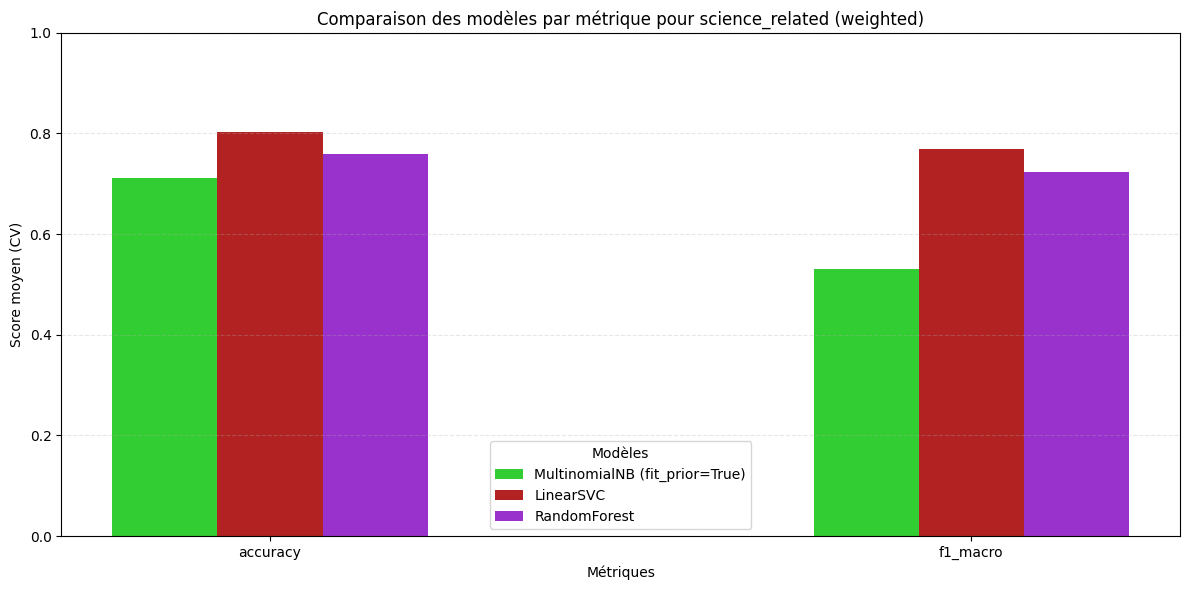

Plot saved to: comparison_modeles_science_related_weighted.png


In [94]:
# for metrique in metriques:
#     fig = plt.figure()
#     fig.suptitle("Comparaison des " + metrique)
#     ax = fig.add_subplot(111)
#     plt.boxplot(results[metrique])
#     ax.set_xticklabels(names)
#     plt.show()

x = np.arange(len(metriques))
width = 0.15
fig, ax = plt.subplots(figsize=(12, 6))
for i, name in enumerate(names):
    model_scores = [np.mean(results[m][i]) for m in metriques]
    ax.bar(x + (i - (len(names) - 1) / 2) * width, model_scores, width, label=name, color=colors[i])
ax.set_title(f"Comparaison des modèles par métrique pour {column}" + (f" ({sampling})" if sampling != "nothing" else ""))
ax.set_xlabel("Métriques")
ax.set_ylabel("Score moyen (CV)")
ax.set_xticks(x)
ax.set_xticklabels(metriques)
ax.set_ylim(0, 1)
ax.legend(title="Modèles", loc="lower center")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

filename = f"comparison_modeles_{column}_{sampling}.png" if sampling != "nothing" else f"comparison_modeles_{column}.png"
fig.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Plot saved to: {filename}")

# Comparaison détaillée entre weighted LinearSVC et Normal LinearSVC

df d'origine : 1140 lignes
 STATS DE FOU : MODÈLE SANS RIEN (DE BASE) 


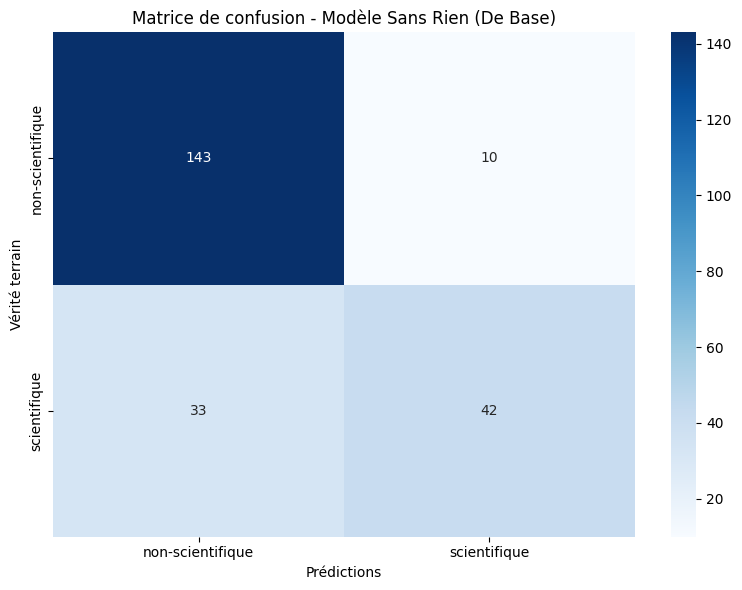

Sur 75 VRAIS tweets de Science :
 Vrais Positifs : 42
 Faux Négatifs: 33
 Rappel sciences : 56.0%
Détail Précision / Rappel par classe :
                    precision    recall  f1-score   support

Classe 0 (Non-Sci)       0.81      0.93      0.87       153
Classe 1 (Science)       0.81      0.56      0.66        75

          accuracy                           0.81       228
         macro avg       0.81      0.75      0.77       228
      weighted avg       0.81      0.81      0.80       228



 STATS DE FOU : MODÈLE WEIGHT BALANCED 


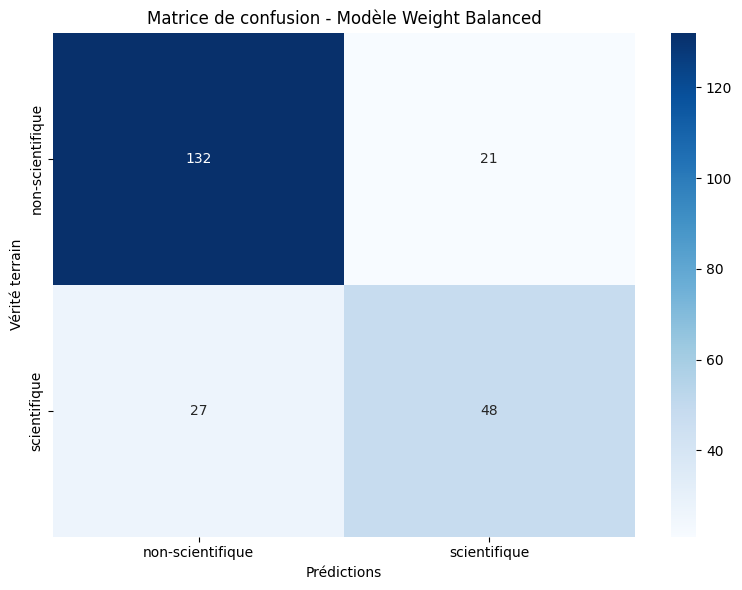

Sur 75 VRAIS tweets de Science :
 Vrais Positifs : 48
 Faux Négatifs: 27
 Rappel sciences : 64.0%
Détail Précision / Rappel par classe :
                    precision    recall  f1-score   support

Classe 0 (Non-Sci)       0.83      0.86      0.85       153
Classe 1 (Science)       0.70      0.64      0.67        75

          accuracy                           0.79       228
         macro avg       0.76      0.75      0.76       228
      weighted avg       0.79      0.79      0.79       228





In [106]:
def plot_confusion_matrix(cm, classes, title='Matrice de confusion', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('Vérité terrain')
    plt.xlabel('Prédictions')
    plt.tight_layout()
    plt.show()

sampling = "nothing" 
column = "science_related"
df_lue = pd.read_csv('scitweets_export.tsv', sep='\t')
print(f"df d'origine : {len(df_lue)} lignes")

# Configuration de l'affichage
tache_res_display = ["Classe 0 (Non-Sci)", "Classe 1 (Science)"]

# 1. Préparation du texte complet
texte = [preprocess(t) for t in df_lue.text]

# 2. Séparation stricte et stratifiée Train / Test (80% / 20%)
X_train_brut, X_test_brut, y_train, y_test = train_test_split(
    texte, df_lue[column], test_size=0.2, stratify=df_lue[column], random_state=42
)

#vectorisation (TF-IDF) sur les données brutes
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=7000, lowercase=False)
X_train_vec = vectorizer.fit_transform(X_train_brut)
X_test_vec  = vectorizer.transform(X_test_brut)

# entrainement des modèles
model_rien = LinearSVC(C=1.0, random_state=42)
model_rien.fit(X_train_vec, y_train)

model_balanced = LinearSVC(C=1.0, class_weight="balanced", random_state=42)
model_balanced.fit(X_train_vec, y_train)

# prédictions sur le test
preds_rien = model_rien.predict(X_test_vec)
preds_balanced = model_balanced.predict(X_test_vec)

def analyser_comportement(y_vrai, y_pred, nom_modele):
    cm = confusion_matrix(y_vrai, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    total_non_science = tn + fp
    total_science = fn + tp
    
    taux_detection_science = (tp / total_science) * 100
    tweets_science_rates = fn
    
    print(f" STATS DE FOU : {nom_modele.upper()} ")
    plot_confusion_matrix(cm, classes=["non-scientifique", "scientifique"], title=f"Matrice de confusion - {nom_modele}")
    print(f"Sur {total_science} VRAIS tweets de Science :")
    print(f" Vrais Positifs : {tp}")
    print(f" Faux Négatifs: {tweets_science_rates}")
    print(f" Rappel sciences : {taux_detection_science:.1f}%")
    print("Détail Précision / Rappel par classe :")
    print(classification_report(y_vrai, y_pred, target_names=["Classe 0 (Non-Sci)", "Classe 1 (Science)"]))
    print("\n")

# Lancement de l'analyse
analyser_comportement(y_test, preds_rien, "Modèle Sans Rien (De Base)")
analyser_comportement(y_test, preds_balanced, "Modèle Weight Balanced")

# Recherche des meilleurs hyperParamètres LinearSVC

In [111]:
def objectiveLinearSVC(trial, X, y, weighted):
    ngram_max = trial.suggest_int("ngram_max", 2, 4)
    param_ngram_range = (1, ngram_max)
    param_max_features = trial.suggest_int("max_features", 8000, 20000, step=500)
    param_min_df = trial.suggest_int("min_df", 1, 4)
    param_max_df = trial.suggest_float("max_df", 0.70, 0.99)
    param_C = trial.suggest_float("C", 0.01, 2, log=True)
    param_max_iter = trial.suggest_int("max_iter", 5000, 20000, step=1000)
    param_penalty = trial.suggest_categorical("penalty", ["l1", "l2"])

    if param_penalty == "l1":
        param_loss = "squared_hinge"
        param_dual = False
    else:
        param_loss = trial.suggest_categorical("loss", ["hinge", "squared_hinge"])
        param_dual = True if param_loss == "hinge" else False

    vectorizer = TfidfVectorizer(
        ngram_range=param_ngram_range,
        max_features=param_max_features,
        min_df=param_min_df,
        max_df=param_max_df,
        lowercase=False,
    )

    model = LinearSVC(
        C=param_C,
        penalty=param_penalty,
        loss=param_loss,
        max_iter=param_max_iter,
        class_weight="balanced" if weighted else None,
        dual=param_dual,
        random_state=42,
    )

    pipeline = Pipeline([("vectorizer", vectorizer), ("model", model)])

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipeline, X, y, cv=kfold, scoring="f1_macro", n_jobs=-1
    )

    return scores.mean()

def saveLinearSVCModel(X, y, path, weighted):
    # Meilleurs paramètres Optuna
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objectiveLinearSVC(trial, X, y, weighted), n_trials=100)

    print(f"Meilleurs paramètres: {study.best_params}")
    print(f"Meilleur score: {study.best_value}")
    
    best_penalty = study.best_params['penalty']
    best_loss = study.best_params.get('loss', 'squared_hinge')  # absent si penalty="l1"
    best_dual = True if best_loss == "hinge" else False

    pipeline_final = Pipeline([
        ("vectorizer", TfidfVectorizer(
            ngram_range=(1, study.best_params['ngram_max']),
            max_features=study.best_params['max_features'],
            min_df=study.best_params['min_df'],
            max_df=study.best_params['max_df'],
            lowercase=False
        )),
        ("model", LinearSVC(
            C=study.best_params['C'],
            penalty=best_penalty,
            loss=best_loss,
            max_iter=study.best_params['max_iter'],
            class_weight="balanced" if weighted else None,
            dual=best_dual,
            random_state=42
        ))
    ])

    # Entraînement du pipeline sur toutes les données disponibles
    pipeline_final.fit(X, y)
    
    # Enregistrement model
    joblib.dump(pipeline_final, path)
    print(f"Modèle sauvegardé sous : {path}")
    print(f"Meilleurs paramètres: {study.best_params}")
    return study.best_value

# Recherche des meilleurs hyperParamètres MultinomialMB

In [112]:
def objectiveMultinomialMB(trial, X, y, weighted):
    ngram_max = trial.suggest_int("ngram_max", 2, 4)
    param_ngram_range = (1, ngram_max)
    param_max_features = trial.suggest_int("max_features", 8000, 20000, step=500)
    param_min_df = trial.suggest_int("min_df", 1, 4)
    param_max_df = trial.suggest_float("max_df", 0.70, 0.99)
    param_alpha = trial.suggest_float("alpha", 1e-3, 10.0, log=True)

    vectorizer = TfidfVectorizer(
        ngram_range=param_ngram_range,
        max_features=param_max_features,
        min_df=param_min_df,
        max_df=param_max_df,
        lowercase=False,
    )
    model = MultinomialNB(
        alpha=param_alpha,
        fit_prior=weighted,
    )

    pipeline_final = Pipeline([("vectorizer", vectorizer), ("model", model)])

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipeline_final, X, y, cv=kfold, scoring="f1_macro", n_jobs=-1
    )

    return scores.mean()


def saveMultinomialNBModel(X, y, path, weighted):
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objectiveMultinomialMB(trial, X, y, weighted), n_trials=100)

    print(f"Meilleurs paramètres: {study.best_params}")
    print(f"Meilleur score: {study.best_value}")

    pipeline_final = Pipeline([
        ("vectorizer", TfidfVectorizer(
            ngram_range=(1, study.best_params['ngram_max']),
            max_features=study.best_params['max_features'],
            min_df=study.best_params['min_df'],
            max_df=study.best_params['max_df'],
            lowercase=False,
        )),
        ("model", MultinomialNB(
            alpha=study.best_params['alpha'],
            fit_prior=weighted,
        ))
    ])

    pipeline_final.fit(X, y)

    # Enregistrement model
    joblib.dump(pipeline_final, path)
    print(f"Modèle sauvegardé sous : {path}")
    print(f"Meilleurs paramètres: {study.best_params}")
    return study.best_value

# Recherche des meilleurs hyperParamètres DecisionTree

In [113]:
def objectiveDecisionTree(trial, X, y):
    ngram_max = trial.suggest_int("ngram_max", 1, 2)
    param_ngram_range = (1, ngram_max)
    param_max_features = trial.suggest_int("max_features", 500, 3000, step=250)

    param_min_df = trial.suggest_int("min_df", 2, 5)
    param_max_df = trial.suggest_float("max_df", 0.70, 0.95)

    param_criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
    
    param_max_depth = trial.suggest_int("max_depth", 10, 60, step=5)
    
    param_min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    param_min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

    param_ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 0.03)

    vectorizer = TfidfVectorizer(
        ngram_range=param_ngram_range,
        max_features=param_max_features,
        min_df=param_min_df,
        max_df=param_max_df,
        lowercase=False,
    )

    model = DecisionTreeClassifier(
        criterion=param_criterion,
        max_depth=param_max_depth,
        min_samples_split=param_min_samples_split,
        min_samples_leaf=param_min_samples_leaf,
        ccp_alpha=param_ccp_alpha,
        random_state=42,
    )

    pipeline = Pipeline([("vectorizer", vectorizer), ("model", model)])

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipeline, X, y, cv=kfold, scoring="f1_macro", n_jobs=-1
    )

    return scores.mean()

def saveDecisionTreeModel(X, y, path):   
    # Meilleurs paramètres Optuna
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objectiveDecisionTree(trial, X, y), n_trials=100)
    
    pipeline_final = Pipeline([
        ("vectorizer", TfidfVectorizer(
            ngram_range=(1, study.best_params['ngram_max']),
            max_features=study.best_params['max_features'],
            min_df=study.best_params['min_df'],
            max_df=study.best_params['max_df'],
            lowercase=False
            )),
        ("model", DecisionTreeClassifier(
            criterion=study.best_params['criterion'],
            max_depth=study.best_params['max_depth'],
            min_samples_split=study.best_params['min_samples_split'],
            min_samples_leaf=study.best_params['min_samples_leaf'],
            ccp_alpha=study.best_params['ccp_alpha'],
            random_state=42
        ))
    ])

    # Entraînement du pipeline sur toutes les données disponibles
    pipeline_final.fit(X, y)
    
    # Enregistrement model
    joblib.dump(pipeline_final, path)
    print(f"Modèle sauvegardé sous : {path}")
    print(f"Meilleurs paramètres: {study.best_params}")
    return study.best_value

# Création et enregistrement des models (moins N tweets)

[I 2026-05-19 22:36:32,941] A new study created in memory with name: no-name-1b834935-2925-4cce-b20b-efc8d3fdab80
[I 2026-05-19 22:36:34,518] Trial 0 finished with value: 0.7009762155924172 and parameters: {'ngram_max': 3, 'max_features': 19000, 'min_df': 2, 'max_df': 0.9306820852746855, 'C': 0.3215948990448488, 'max_iter': 19000, 'penalty': 'l1'}. Best is trial 0 with value: 0.7009762155924172.
[I 2026-05-19 22:36:35,351] Trial 1 finished with value: 0.7664857558898006 and parameters: {'ngram_max': 3, 'max_features': 13500, 'min_df': 2, 'max_df': 0.7028726117715552, 'C': 1.5075200543641605, 'max_iter': 14000, 'penalty': 'l2', 'loss': 'hinge'}. Best is trial 1 with value: 0.7664857558898006.
[I 2026-05-19 22:36:36,164] Trial 2 finished with value: 0.7616682590825237 and parameters: {'ngram_max': 3, 'max_features': 15500, 'min_df': 3, 'max_df': 0.7117896782658648, 'C': 0.01771148272333428, 'max_iter': 20000, 'penalty': 'l2', 'loss': 'hinge'}. Best is trial 1 with value: 0.76648575588980

Meilleurs paramètres: {'ngram_max': 2, 'max_features': 12500, 'min_df': 1, 'max_df': 0.9137265561984262, 'C': 0.03580077509128124, 'max_iter': 16000, 'penalty': 'l2', 'loss': 'squared_hinge'}
Meilleur score: 0.7914490715135676


[I 2026-05-19 22:36:41,100] A new study created in memory with name: no-name-8533ed41-74c8-43c5-b225-77427e6d3f1e
[I 2026-05-19 22:36:41,143] Trial 0 finished with value: 0.7520904384439094 and parameters: {'ngram_max': 2, 'max_features': 19000, 'min_df': 1, 'max_df': 0.9347835153082192, 'alpha': 0.13136787636704905}. Best is trial 0 with value: 0.7520904384439094.
[I 2026-05-19 22:36:41,196] Trial 1 finished with value: 0.67940353259006 and parameters: {'ngram_max': 3, 'max_features': 18000, 'min_df': 4, 'max_df': 0.7916162441934226, 'alpha': 0.39292001073429683}. Best is trial 0 with value: 0.7520904384439094.
[I 2026-05-19 22:36:41,250] Trial 2 finished with value: 0.7571144189731744 and parameters: {'ngram_max': 3, 'max_features': 8000, 'min_df': 1, 'max_df': 0.8399568099658467, 'alpha': 0.14582206444384885}. Best is trial 2 with value: 0.7571144189731744.


Modèle sauvegardé sous : scienceRelatedModel.joblib
Meilleurs paramètres: {'ngram_max': 2, 'max_features': 12500, 'min_df': 1, 'max_df': 0.9137265561984262, 'C': 0.03580077509128124, 'max_iter': 16000, 'penalty': 'l2', 'loss': 'squared_hinge'}


[I 2026-05-19 22:36:41,315] Trial 3 finished with value: 0.6897309679596267 and parameters: {'ngram_max': 4, 'max_features': 20000, 'min_df': 4, 'max_df': 0.896850527890413, 'alpha': 0.072192402762765}. Best is trial 2 with value: 0.7571144189731744.
[I 2026-05-19 22:36:41,389] Trial 4 finished with value: 0.7230789087026356 and parameters: {'ngram_max': 4, 'max_features': 17500, 'min_df': 2, 'max_df': 0.9374515361612079, 'alpha': 0.0499563161821}. Best is trial 2 with value: 0.7571144189731744.
[I 2026-05-19 22:36:41,455] Trial 5 finished with value: 0.6813606740558399 and parameters: {'ngram_max': 4, 'max_features': 8500, 'min_df': 4, 'max_df': 0.9011420046242946, 'alpha': 0.006319370987825928}. Best is trial 2 with value: 0.7571144189731744.
[I 2026-05-19 22:36:41,508] Trial 6 finished with value: 0.6991071960861432 and parameters: {'ngram_max': 3, 'max_features': 15000, 'min_df': 1, 'max_df': 0.827457334120898, 'alpha': 3.5488544674048157}. Best is trial 2 with value: 0.75711441897

Meilleurs paramètres: {'ngram_max': 3, 'max_features': 10000, 'min_df': 1, 'max_df': 0.8483741500786556, 'alpha': 0.08437854233606576}
Meilleur score: 0.7669058890278937
Modèle sauvegardé sous : scientificClaimModel.joblib
Meilleurs paramètres: {'ngram_max': 3, 'max_features': 10000, 'min_df': 1, 'max_df': 0.8483741500786556, 'alpha': 0.08437854233606576}


[I 2026-05-19 22:36:46,832] Trial 1 finished with value: 0.5776927392703562 and parameters: {'ngram_max': 1, 'max_features': 1250, 'min_df': 5, 'max_df': 0.8426056897254122, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 5, 'ccp_alpha': 0.008730601909220016}. Best is trial 1 with value: 0.5776927392703562.
[I 2026-05-19 22:36:46,887] Trial 2 finished with value: 0.6401340079586871 and parameters: {'ngram_max': 1, 'max_features': 1500, 'min_df': 2, 'max_df': 0.8819728308057816, 'criterion': 'gini', 'max_depth': 50, 'min_samples_split': 15, 'min_samples_leaf': 3, 'ccp_alpha': 0.004214049649698875}. Best is trial 2 with value: 0.6401340079586871.
[I 2026-05-19 22:36:46,921] Trial 3 finished with value: 0.602802493560145 and parameters: {'ngram_max': 1, 'max_features': 2000, 'min_df': 2, 'max_df': 0.7893194842734187, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 6, 'ccp_alpha': 0.006663632209415404}. Best is trial

Modèle sauvegardé sous : scientificReferenceModel.joblib
Meilleurs paramètres: {'ngram_max': 1, 'max_features': 3000, 'min_df': 2, 'max_df': 0.8625909765584884, 'criterion': 'gini', 'max_depth': 40, 'min_samples_split': 15, 'min_samples_leaf': 3, 'ccp_alpha': 0.001664344470605476}


[I 2026-05-19 22:36:51,618] Trial 3 finished with value: 0.718953549669188 and parameters: {'ngram_max': 4, 'max_features': 17500, 'min_df': 3, 'max_df': 0.8319938531285478, 'C': 1.8869665170715555, 'max_iter': 5000, 'penalty': 'l2', 'loss': 'hinge'}. Best is trial 3 with value: 0.718953549669188.
[I 2026-05-19 22:36:51,672] Trial 4 finished with value: 0.43794284008727463 and parameters: {'ngram_max': 3, 'max_features': 17500, 'min_df': 4, 'max_df': 0.7849186994239187, 'C': 0.013521019066967992, 'max_iter': 9000, 'penalty': 'l2', 'loss': 'hinge'}. Best is trial 3 with value: 0.718953549669188.
[I 2026-05-19 22:36:51,749] Trial 5 finished with value: 0.6720784201875138 and parameters: {'ngram_max': 2, 'max_features': 8500, 'min_df': 2, 'max_df': 0.7462986695287666, 'C': 0.636216731518756, 'max_iter': 19000, 'penalty': 'l1'}. Best is trial 3 with value: 0.718953549669188.
[I 2026-05-19 22:36:51,814] Trial 6 finished with value: 0.6177283700988008 and parameters: {'ngram_max': 3, 'max_fe

Meilleurs paramètres: {'ngram_max': 4, 'max_features': 15000, 'min_df': 2, 'max_df': 0.977295931645453, 'C': 1.9869618321280909, 'max_iter': 16000, 'penalty': 'l2', 'loss': 'hinge'}
Meilleur score: 0.7298181365371331
Modèle sauvegardé sous : scientificContextModel.joblib
Meilleurs paramètres: {'ngram_max': 4, 'max_features': 15000, 'min_df': 2, 'max_df': 0.977295931645453, 'C': 1.9869618321280909, 'max_iter': 16000, 'penalty': 'l2', 'loss': 'hinge'}


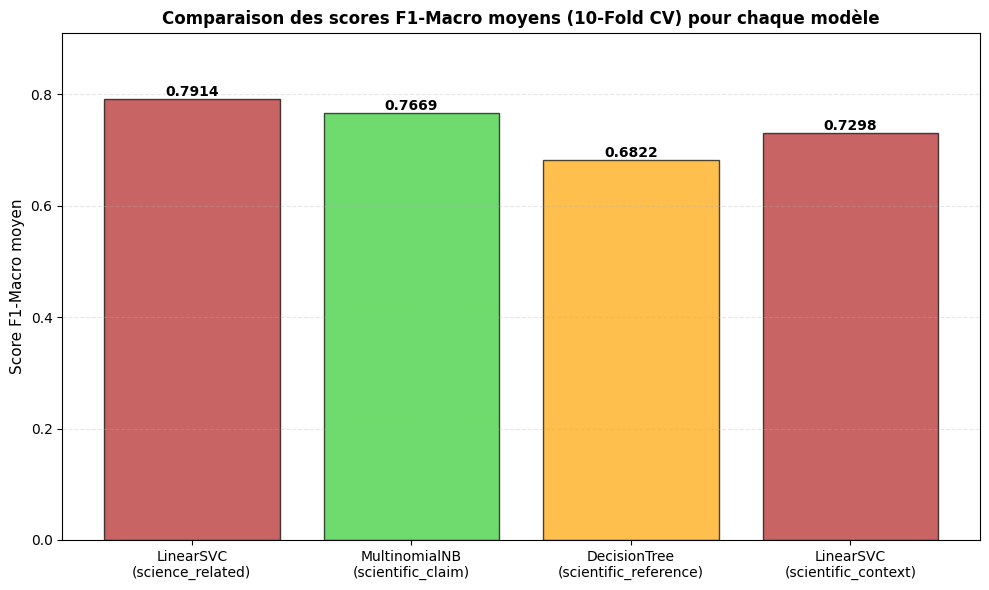


Résumé des scores finaux des modèles:
LinearSVC (science_related): 0.7914
MultinomialNB (scientific_claim): 0.7669
DecisionTree (scientific_reference): 0.6822
LinearSVC (scientific_context): 0.7298


In [117]:
N = 10

df = pd.read_csv('scitweets_export.tsv', sep='\t')
df["text"] = [preprocess(t) for t in df["text"]]

df_test_global = df.sample(n=N, random_state=0)
df_train_global = df.drop(df_test_global.index)

df_scientific = df[df["science_related"] == 1].reset_index(drop=True)
df_test_scientific = df.sample(n=N, random_state=0)
df_train_scientific = df.drop(df_test_scientific.index)

scienceRelatedModelScore = saveLinearSVCModel(df_train_global["text"], df_train_global["science_related"].values, "scienceRelatedModel.joblib", weighted=True)
scientificClaimModelScore = saveMultinomialNBModel(df_train_scientific["text"], df_train_scientific["scientific_claim"].values, "scientificClaimModel.joblib", weighted=False)
scientificReferenceModelScore = saveDecisionTreeModel(df_train_scientific["text"], df_train_scientific["scientific_reference"].values, "scientificReferenceModel.joblib") # normal (pas sample)
scientificContextModelScore = saveLinearSVCModel(df_train_scientific["text"], df_train_scientific["scientific_context"].values, "scientificContextModel.joblib", weighted=False)

# Create comparison plot for model scores
model_names = ["LinearSVC\n(science_related)", "MultinomialNB\n(scientific_claim)", 
               "DecisionTree\n(scientific_reference)", "LinearSVC\n(scientific_context)"]
model_scores = [scienceRelatedModelScore, scientificClaimModelScore, 
                scientificReferenceModelScore, scientificContextModelScore]
colors_models = ["firebrick", "limegreen", "orange", "firebrick"]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, model_scores, color=colors_models, alpha=0.7, edgecolor='black')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title("Comparaison des scores F1-Macro moyens (10-Fold CV) pour chaque modèle", fontsize=12, fontweight='bold')
ax.set_ylabel("Score F1-Macro moyen", fontsize=11)
ax.set_ylim(0, max(model_scores) * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRésumé des scores finaux des modèles:")
for name, score in zip(model_names, model_scores):
    print(f"{name.replace(chr(10), ' ')}: {score:.4f}")

# Chargement des models

In [100]:
# Rechargement du modèle
scienceRelatedModel = joblib.load("scienceRelatedModel.joblib")
scientificClaimModel = joblib.load("scientificClaimModel.joblib")
scientificReferenceModel = joblib.load("scientificReferenceModel.joblib")
scientificContextModel = joblib.load("scientificContextModel.joblib")

# Fonction predict

In [115]:
def predict_task(task, df_global, df_scientific, texttest=None):
    if texttest is not None:
        Xdf = pd.DataFrame({"text": texttest})
    elif task == "Related":
        Xdf = df_global.copy()
    else:
        Xdf = df_scientific.copy()

    X = Xdf["text"]

    # Colonnes ground truth disponibles dans Xdf
    gt_cols = [c for c in ["science_related", "scientific_claim", "scientific_reference", "scientific_context"] if c in Xdf.columns]

    if task == "Related":
        y = scienceRelatedModel.predict(X)
        res = Xdf.copy()
        res["Science related"] = y
        cols = ["text", "Science related"] + gt_cols
        display(res[cols])
        return res[cols]

    elif task == "Knowledge&Context" or task == "Claim&Context&Reference":
        yclaim     = scientificClaimModel.predict(X)
        yreference = scientificReferenceModel.predict(X)
        ycontext   = scientificContextModel.predict(X)

        res = Xdf.copy()

        if task == "Knowledge&Context":
            res["Scientific Knowledge"] = [max(yclaim[i], ycontext[i]) for i in range(len(yclaim))]
            res["Scientific Context"]   = ycontext
            cols = ["text", "Scientific Knowledge", "Scientific Context"] + gt_cols
            display(res[cols])
            return res[cols]
        elif task == "Claim&Context&Reference":
            res["Scientific Claim"]     = yclaim
            res["Scientific Context"]   = ycontext
            res["Scientific Reference"] = yreference
            cols = ["text", "Scientific Claim", "Scientific Context", "Scientific Reference"] + gt_cols
            display(res[cols])
            return res[cols]

    else:
        raise ValueError(f"Unknown task: {task}")

# Predict des N derniers tweets

In [116]:
predict_task("Related", df_test_global, df_test_scientific)
predict_task("Knowledge&Context", df_test_global, df_test_scientific)
predict_task("Claim&Context&Reference", df_test_global, df_test_scientific)
print()

,text,Science related,science_related,scientific_claim,scientific_reference,scientific_context
1014,stop broadcast press briefing control cycle,0,0,0.0,0.0,0.0
878,palm use successfully purpose non - parametric...,1,1,0.0,0.0,1.0
1070,new age initiative new face fanism fellowship ...,0,0,0.0,0.0,0.0
184,social medium unnecessary thing caus drama,1,0,0.0,0.0,0.0
685,concept stop mean people reason,0,0,0.0,0.0,0.0
936,"load "" sport drink stay hydrated want reconsid...",1,1,1.0,1.0,1.0
567,rememb libs attack conceal carri stance right ...,0,0,0.0,0.0,0.0
891,play early year important complete disappearan...,1,1,1.0,0.0,0.0
1083,upper west resident furious consid su new york...,1,0,0.0,0.0,0.0
569,ice cream sweet treat,0,0,0.0,0.0,0.0


,text,Scientific Knowledge,Scientific Context,science_related,scientific_claim,scientific_reference,scientific_context
1014,stop broadcast press briefing control cycle,1.0,0.0,0,0.0,0.0,0.0
878,palm use successfully purpose non - parametric...,1.0,1.0,1,0.0,0.0,1.0
1070,new age initiative new face fanism fellowship ...,0.0,0.0,0,0.0,0.0,0.0
184,social medium unnecessary thing caus drama,0.0,0.0,0,0.0,0.0,0.0
685,concept stop mean people reason,0.0,0.0,0,0.0,0.0,0.0
936,"load "" sport drink stay hydrated want reconsid...",1.0,0.0,1,1.0,1.0,1.0
567,rememb libs attack conceal carri stance right ...,0.0,0.0,0,0.0,0.0,0.0
891,play early year important complete disappearan...,1.0,1.0,1,1.0,0.0,0.0
1083,upper west resident furious consid su new york...,1.0,1.0,0,0.0,0.0,0.0
569,ice cream sweet treat,0.0,0.0,0,0.0,0.0,0.0


,text,Scientific Claim,Scientific Context,Scientific Reference,science_related,scientific_claim,scientific_reference,scientific_context
1014,stop broadcast press briefing control cycle,1.0,0.0,0.0,0,0.0,0.0,0.0
878,palm use successfully purpose non - parametric...,1.0,1.0,1.0,1,0.0,0.0,1.0
1070,new age initiative new face fanism fellowship ...,0.0,0.0,0.0,0,0.0,0.0,0.0
184,social medium unnecessary thing caus drama,0.0,0.0,0.0,0,0.0,0.0,0.0
685,concept stop mean people reason,0.0,0.0,0.0,0,0.0,0.0,0.0
936,"load "" sport drink stay hydrated want reconsid...",1.0,0.0,1.0,1,1.0,1.0,1.0
567,rememb libs attack conceal carri stance right ...,0.0,0.0,0.0,0,0.0,0.0,0.0
891,play early year important complete disappearan...,1.0,1.0,0.0,1,1.0,0.0,0.0
1083,upper west resident furious consid su new york...,0.0,1.0,0.0,0,0.0,0.0,0.0
569,ice cream sweet treat,0.0,0.0,0.0,0,0.0,0.0,0.0


In [103]:
predict_task("Related", ["I love science"])
predict_task("Knowledge&Context", ["I hate science"])
predict_task("Claim&Context&Reference", ["child labour"]) # (mot overfit)
print()

,text,Science related
0,I love science,1


,text,Scientific Knowledge,Scientific Context
0,I hate science,0.0,0.0


,text,Scientific Claim,Scientific Context,Scientific Reference
0,child labour,1.0,0.0,0.0
